# Лабораторная работа 2
## Метод главных компонент (PCA) и k-ближайших соседей (kNN) на MNIST

В этой работе я:

1. загружаю изображения рукописных цифр MNIST;
2. реализую PCA самостоятельно через SVD;
3. реализую классификатор kNN самостоятельно;
4. сравниваю свои реализации со `scikit-learn`;
5. исследую влияние числа компонент PCA и числа соседей `k`;
6. отдельно измеряю PCA-fit, преобразование данных, kNN и полное время PCA + kNN;
7. показываю точность для пар «число компонент × число соседей» на тепловой карте и 3D-графике.

Для воспроизводимости используется стратифицированная рабочая выборка из 20 000 изображений. Для основного сравнения PCA обучается только на обучающей части, чтобы не использовать тестовые данные при обучении.


## Размер рабочей выборки и время экспериментов

MNIST содержит 60 000 обучающих и 10 000 тестовых изображений. В работе используется стратифицированная выборка из `WORKING_SAMPLES = 20_000` обучающих изображений MNIST; затем она делится на 70% для обучения и 30% для тестирования. Так увеличивается объём эксперимента, но остаются доступны классы всех цифр.

Полный SVD и kNN на 20 000 изображениях могут работать заметно дольше, чем на 5 000. PCA обучается один раз на train-части, а полученные компоненты переиспользуются в экспериментах. Время PCA-fit, преобразования train/test, fit/predict kNN и их сумму программа считает отдельно, чтобы не называть временем PCA + kNN только поиск соседей.


In [1]:
# Подключаю модуль, который умеет проверять наличие Python-пакетов.
import importlib.util
# Подключаю sys, чтобы установка выполнялась именно в Python текущего ядра VS Code.
import sys
# Подключаю subprocess для запуска pip из текущего интерпретатора Python.
import subprocess

# Создаю словарь: имя модуля -> имя пакета для установки.
required_packages = {
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "sklearn": "scikit-learn",
    "seaborn": "seaborn",
}
# Создаю список только для отсутствующих пакетов.
missing_packages = []
# Проверяю каждый необходимый модуль.
for module_name, package_name in required_packages.items():
    # Если модуль не найден, добавляю соответствующий пакет в список установки.
    if importlib.util.find_spec(module_name) is None:
        missing_packages.append(package_name)

# Устанавливаю только отсутствующие библиотеки и не трогаю уже рабочее окружение.
if missing_packages:
    print("Устанавливаю библиотеки:", ", ".join(missing_packages))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing_packages])
    print("Установка завершена.")
# Если всё уже установлено, сообщаю об этом.
else:
    print("Все необходимые библиотеки уже установлены.")


Все необходимые библиотеки уже установлены.


In [2]:
# Подключаю NumPy для массивов, матриц и линейной алгебры.
import numpy as np
# Подключаю Matplotlib для изображений и графиков.
import matplotlib.pyplot as plt
# Подключаю Seaborn для красивой тепловой карты.
import seaborn as sns
# Подключаю стандартные модули для скачивания и распаковки MNIST.
import gzip
import struct
import time
from pathlib import Path
from urllib.request import urlretrieve
# Подключаю функции из scikit-learn только для проверки и сравнения.
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA as SklearnPCA
from sklearn.neighbors import KNeighborsClassifier

# Фиксирую генератор случайных чисел, чтобы результаты можно было повторить.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
# Использую увеличенную стратифицированную выборку по замечанию преподавателя.
WORKING_SAMPLES = 20_000
# Создаю папку, в которую можно сохранять графики и результаты.
RESULTS_DIR = Path("attached_assets") / "mnist_pca_knn_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
# Вывожу версии основных библиотек для проверки окружения.
print("NumPy:", np.__version__)
print("Рабочая папка для результатов:", RESULTS_DIR)


NumPy: 2.5.3
Рабочая папка для результатов: attached_assets\mnist_pca_knn_results


In [3]:
# Указываю официальный доступный URL с файлами MNIST.
MNIST_URL = "https://storage.googleapis.com/cvdf-datasets/mnist/"
# Создаю папку для скачанных архивов MNIST.
MNIST_DIR = Path("MNIST-data")
MNIST_DIR.mkdir(parents=True, exist_ok=True)

# Описываю четыре файла: картинки и правильные ответы для train и test.
MNIST_FILES = {
    "train_images": "train-images-idx3-ubyte.gz",
    "train_labels": "train-labels-idx1-ubyte.gz",
    "test_images": "t10k-images-idx3-ubyte.gz",
    "test_labels": "t10k-labels-idx1-ubyte.gz",
}

# Скачиваю файл только тогда, когда его ещё нет на компьютере.
def download_mnist_file(filename):
    # Формирую локальный путь к нужному архиву.
    local_path = MNIST_DIR / filename
    # Проверяю, нужно ли скачивание.
    if not local_path.exists():
        print("Скачиваю", filename)
        urlretrieve(MNIST_URL + filename, local_path)
    # Возвращаю путь к готовому локальному файлу.
    return local_path

# Читаю архив с изображениями MNIST и превращаю его в массив.
def read_images(filename):
    # Открываю gzip-архив в бинарном режиме.
    with gzip.open(filename, "rb") as file:
        # Заголовок содержит код формата, число изображений, строки и столбцы.
        magic, count, rows, cols = struct.unpack(">IIII", file.read(16))
        # Проверяю код формата изображений.
        if magic != 2051:
            raise ValueError(f"Неожиданный код изображений: {magic}")
        # Читаю все пиксели и преобразую байты в числа от 0 до 255.
        data = np.frombuffer(file.read(), dtype=np.uint8)
        # Возвращаю форму (число изображений, 28, 28, 1).
        return data.reshape(count, rows, cols, 1)

# Читаю архив с метками цифр.
def read_labels(filename):
    # Открываю gzip-архив с метками.
    with gzip.open(filename, "rb") as file:
        # Заголовок содержит код формата и число меток.
        magic, count = struct.unpack(">II", file.read(8))
        # Проверяю код формата меток.
        if magic != 2049:
            raise ValueError(f"Неожиданный код меток: {magic}")
        # Возвращаю массив правильных цифр.
        return np.frombuffer(file.read(), dtype=np.uint8).reshape(count)

# Загружаю все четыре файла, при необходимости скачивая их.
train_images = read_images(download_mnist_file(MNIST_FILES["train_images"]))
train_labels = read_labels(download_mnist_file(MNIST_FILES["train_labels"]))
test_images = read_images(download_mnist_file(MNIST_FILES["test_images"]))
test_labels = read_labels(download_mnist_file(MNIST_FILES["test_labels"]))

# Показываю исходные размеры данных.
print("Обучающие изображения:", train_images.shape)
print("Обучающие метки:", train_labels.shape)
print("Тестовые изображения:", test_images.shape)
print("Тестовые метки:", test_labels.shape)


Обучающие изображения: (60000, 28, 28, 1)
Обучающие метки: (60000,)
Тестовые изображения: (10000, 28, 28, 1)
Тестовые метки: (10000,)


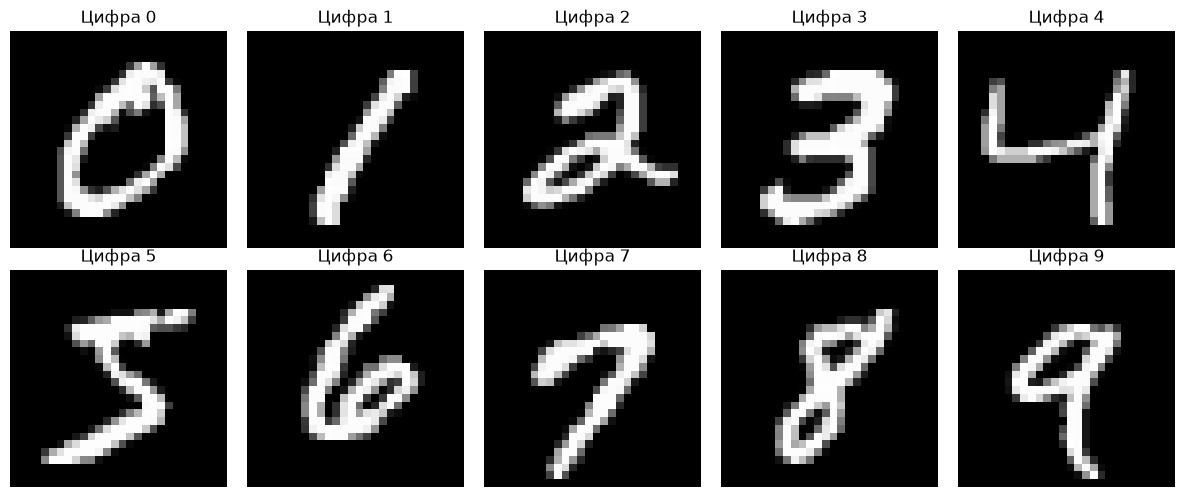

In [4]:
# Создаю сетку из десяти изображений.
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
# Беру по одному примеру каждой цифры от 0 до 9.
for digit, axis in enumerate(axes.ravel()):
    # Находим первое изображение с нужной меткой.
    image_index = np.flatnonzero(train_labels == digit)[0]
    # Показываю картинку в оттенках серого.
    axis.imshow(train_images[image_index].reshape(28, 28), cmap="gray")
    # Подписываю цифру.
    axis.set_title(f"Цифра {digit}")
    # Убираю координатные оси, чтобы рисунок был чище.
    axis.axis("off")
# Автоматически выравниваю элементы рисунка.
plt.tight_layout()
# Сохраняю рисунок в папку результатов.
plt.savefig(RESULTS_DIR / "mnist_examples.png", dpi=150)
# Показываю рисунок.
plt.show()


In [5]:
# Создаю индексы всех обучающих изображений MNIST.
all_train_indices = np.arange(train_images.shape[0])
# Случайно выбираю WORKING_SAMPLES изображений с сохранением доли каждой цифры.
selected_indices, _ = train_test_split(
    all_train_indices,
    train_size=WORKING_SAMPLES,
    stratify=train_labels,
    random_state=RANDOM_STATE,
)
# Выбираю изображения и разворачиваю каждое изображение 28x28 в вектор из 784 пикселей.
X_work = train_images[selected_indices].reshape(len(selected_indices), -1)
# Перевожу пиксели в float32 и нормализую значения из 0..255 в 0..1.
X_work = X_work.astype(np.float32) / 255.0
# Выбираю метки тех же изображений.
y_work = train_labels[selected_indices].astype(np.int64)

# Сначала делю данные, а PCA далее обучаю только на X_train.
# Это исключает утечку тестовых изображений при обучении PCA.
train_indices, test_indices = train_test_split(
    np.arange(len(X_work)),
    test_size=0.30,
    stratify=y_work,
    random_state=RANDOM_STATE,
)
X_train, X_test = X_work[train_indices], X_work[test_indices]
y_train, y_test = y_work[train_indices], y_work[test_indices]

# Вывожу размеры и проверяю диапазон данных.
print("Рабочая подвыборка:", X_work.shape)
print("Обучающая часть:", X_train.shape)
print("Тестовая часть:", X_test.shape)
print("Диапазон пикселей:", X_work.min(), "..", X_work.max())
print("Классы:", np.unique(y_work))


Рабочая подвыборка: (20000, 784)
Обучающая часть: (14000, 784)
Тестовая часть: (6000, 784)
Диапазон пикселей: 0.0 .. 1.0
Классы: [0 1 2 3 4 5 6 7 8 9]


In [6]:
# Собственная реализация метода главных компонент через SVD.
class my_PCA:
    # n_components=None означает сохранение всех доступных компонент.
    def __init__(self, n_components=None):
        self.n_components = n_components
        self.components_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None
        self.mean_ = None
        self.n_components_ = None

    # Обучаю PCA на матрице размера (число объектов, число признаков).
    def fit(self, X):
        X = np.asarray(X, dtype=np.float32)
        if X.ndim != 2:
            raise ValueError("X должен иметь форму (число объектов, число признаков)")
        # Запоминаю среднее и центрирую обучающие данные.
        self.mean_ = np.mean(X, axis=0)
        X_centered = X - self.mean_
        # SVD даёт главные направления в строках Vt.
        _, singular_values, Vt = np.linalg.svd(X_centered, full_matrices=False)
        max_components = Vt.shape[0]
        if self.n_components is None:
            component_count = max_components
        else:
            component_count = int(self.n_components)
            if component_count < 1 or component_count > max_components:
                raise ValueError(f"n_components должен быть от 1 до {max_components}")
        self.components_ = Vt[:component_count]
        self.explained_variance_ = (singular_values ** 2 / max(1, X.shape[0] - 1))[:component_count]
        total_variance = np.sum(singular_values ** 2 / max(1, X.shape[0] - 1))
        self.explained_variance_ratio_ = self.explained_variance_ / total_variance
        self.n_components_ = component_count
        return self

    # Проецирую данные на первые n_components компонент.
    # Если n_components=None, использую все компоненты, сохранённые при fit.
    def transform(self, X, n_components=None):
        if self.components_ is None:
            raise RuntimeError("Сначала нужно вызвать fit")
        if n_components is None:
            component_count = self.components_.shape[0]
        else:
            component_count = int(n_components)
            if component_count < 1 or component_count > self.components_.shape[0]:
                raise ValueError(
                    f"n_components должен быть от 1 до {self.components_.shape[0]}"
                )
        X_centered = np.asarray(X, dtype=np.float32) - self.mean_
        return X_centered @ self.components_[:component_count].T

    # Обучаю PCA и сразу преобразую данные.
    def fit_transform(self, X):
        return self.fit(X).transform(X)

    # Восстанавливаю исходные признаки по числу компонент во входной матрице.
    def inverse_transform(self, X_transformed):
        if self.components_ is None:
            raise RuntimeError("Сначала нужно вызвать fit")
        X_transformed = np.asarray(X_transformed, dtype=np.float32)
        component_count = X_transformed.shape[1]
        if component_count > self.components_.shape[0]:
            raise ValueError("В преобразованных данных больше компонент, чем PCA знает")
        return X_transformed @ self.components_[:component_count] + self.mean_


In [7]:
# Замеряю время обучения PCA отдельно.
# PCA обучается только на train, без использования тестовых данных.
pca_full = my_PCA()
pca_fit_start = time.perf_counter()
pca_full.fit(X_train)
pca_fit_time = time.perf_counter() - pca_fit_start

# Для графиков и восстановления достаточно первых 30 компонент.
visualization_components = min(30, pca_full.n_components_)
pca_visualization_start = time.perf_counter()
Y_work = pca_full.transform(X_work, n_components=visualization_components)
pca_visualization_transform_time = time.perf_counter() - pca_visualization_start

print("Число компонент, найденных PCA:", pca_full.n_components_)
print("Компонент используется для визуализации:", visualization_components)
print("Форма матрицы компонент:", pca_full.components_.shape)
print("Форма координат для визуализации:", Y_work.shape)
print(f"Время обучения PCA на train: {pca_fit_time:.2f} с")
print(f"Время проекции выборки для визуализации: {pca_visualization_transform_time:.2f} с")

# Считаю долю дисперсии первых 15 компонент.
variance_15 = np.sum(pca_full.explained_variance_ratio_[:15])
# Находжу минимальное число компонент для 95 процентов дисперсии.
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
components_for_95 = int(np.searchsorted(cumulative_variance, 0.95) + 1)
print(f"Доля дисперсии первых 15 компонент: {variance_15:.4f} ({variance_15:.2%})")
print(f"Компонент для 95% дисперсии: {components_for_95}")

# Проверяю восстановление по первым 30 компонентам без повторного обучения SVD.
reconstruction_components = min(30, visualization_components)
Y_reduced_for_reconstruction = Y_work[:, :reconstruction_components]
X_reconstructed = pca_full.inverse_transform(Y_reduced_for_reconstruction)
reconstruction_mse = np.mean((X_work - X_reconstructed) ** 2)
print(f"MSE восстановления при {reconstruction_components} компонентах: {reconstruction_mse:.6f}")


Число компонент, найденных PCA: 784
Компонент используется для визуализации: 30
Форма матрицы компонент: (784, 784)
Форма координат для визуализации: (20000, 30)
Время обучения PCA на train: 3.81 с
Время проекции выборки для визуализации: 0.03 с
Доля дисперсии первых 15 компонент: 0.5796 (57.96%)
Компонент для 95% дисперсии: 153
MSE восстановления при 30 компонентах: 0.018161


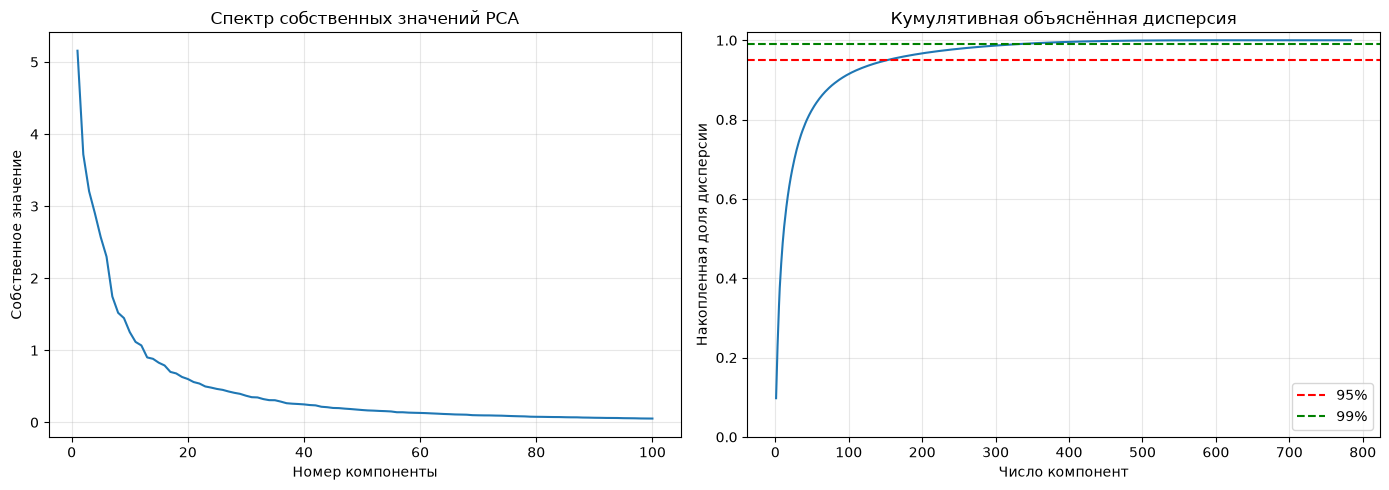

In [8]:
# Создаю область с двумя графиками.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Строю график собственных значений первых 100 компонент.
show_count = min(100, len(pca_full.explained_variance_))
axes[0].plot(np.arange(1, show_count + 1), pca_full.explained_variance_[:show_count])
axes[0].set_xlabel("Номер компоненты")
axes[0].set_ylabel("Собственное значение")
axes[0].set_title("Спектр собственных значений PCA")
axes[0].grid(True, alpha=0.3)
# Строю график накопленной доли объяснённой дисперсии.
axes[1].plot(np.arange(1, len(cumulative_variance) + 1), cumulative_variance)
# Отмечаю уровни 95 и 99 процентов.
axes[1].axhline(0.95, color="red", linestyle="--", label="95%")
axes[1].axhline(0.99, color="green", linestyle="--", label="99%")
axes[1].set_xlabel("Число компонент")
axes[1].set_ylabel("Накопленная доля дисперсии")
axes[1].set_title("Кумулятивная объяснённая дисперсия")
axes[1].set_ylim(0, 1.02)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
# Сохраняю и показываю рисунок.
plt.tight_layout()
plt.savefig(RESULTS_DIR / "pca_variance.png", dpi=150)
plt.show()


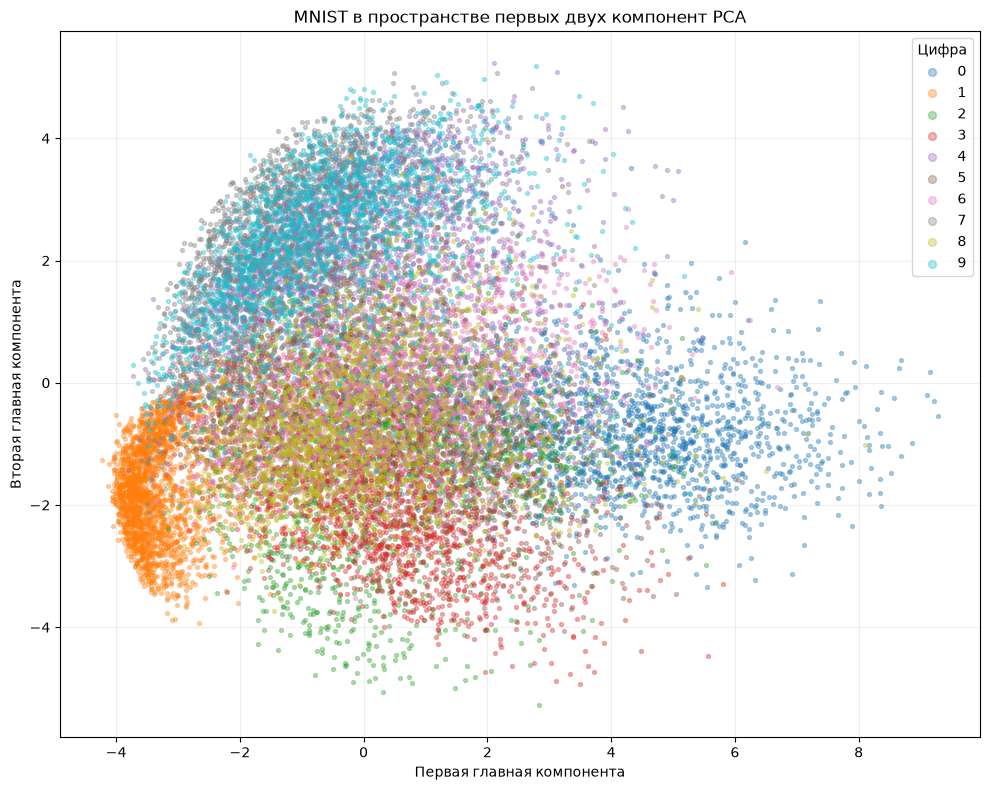

In [9]:
# Для двумерного графика использую первые две компоненты уже обученного PCA.
# Повторный SVD не выполняется.
Y_2d = Y_work[:, :2]
plt.figure(figsize=(10, 8))
for digit in range(10):
    mask = y_work == digit
    plt.scatter(Y_2d[mask, 0], Y_2d[mask, 1], s=8, alpha=0.35, label=str(digit))
plt.xlabel("Первая главная компонента")
plt.ylabel("Вторая главная компонента")
plt.title("MNIST в пространстве первых двух компонент PCA")
plt.legend(title="Цифра", markerscale=2)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "pca_2d.png", dpi=150)
plt.show()


In [10]:
# Создаю собственную реализацию k ближайших соседей.
class my_kNN:
    # Запоминаю число соседей.
    def __init__(self, n_neighbors=5):
        # Проверяю, что число соседей положительное.
        if int(n_neighbors) < 1:
            raise ValueError("n_neighbors должен быть положительным")
        # Сохраняю параметр классификатора.
        self.n_neighbors = int(n_neighbors)
        # Эти поля заполняются при вызове fit.
        self.X_train = None
        self.y_train = None

    # Обучение kNN состоит в запоминании обучающей выборки.
    def fit(self, X, y):
        # Сохраняю признаки в формате float32 для меньшего расхода памяти.
        self.X_train = np.asarray(X, dtype=np.float32)
        # Сохраняю метки классов.
        self.y_train = np.asarray(y, dtype=np.int64)
        # Проверяю согласованность числа объектов и меток.
        if self.X_train.shape[0] != self.y_train.shape[0]:
            raise ValueError("Число объектов и меток должно совпадать")
        # Проверяю, что k не больше обучающей выборки.
        if self.n_neighbors > self.X_train.shape[0]:
            raise ValueError("n_neighbors не может быть больше числа обучающих объектов")
        # Возвращаю сам классификатор.
        return self

    # Нахожу индексы ближайших соседей сразу для нескольких объектов.
    def _nearest_indices(self, X, max_neighbors):
        # Проверяю, что модель уже обучена.
        if self.X_train is None:
            raise RuntimeError("Сначала нужно вызвать fit")
        # Привожу вход к двумерной матрице float32.
        X = np.asarray(X, dtype=np.float32)
        # Не создаю огромную матрицу расстояний целиком, а обрабатываю блоки.
        batch_size = 256
        # Создаю список блоков с индексами ближайших соседей.
        all_neighbor_indices = []
        # Обрабатываю тестовые объекты небольшими блоками.
        for start in range(0, X.shape[0], batch_size):
            # Определяю конец текущего блока.
            stop = min(start + batch_size, X.shape[0])
            # Выбираю текущий блок тестовых объектов.
            batch = X[start:stop]
            # Считаю квадрат нормы каждого объекта тестового блока.
            batch_norm = np.sum(batch * batch, axis=1, keepdims=True)
            # Считаю квадрат нормы каждого обучающего объекта.
            train_norm = np.sum(self.X_train * self.X_train, axis=1)[None, :]
            # Использую формулу ||a-b||^2 = ||a||^2 + ||b||^2 - 2*a*b.
            distances = batch_norm + train_norm - 2.0 * (batch @ self.X_train.T)
            # Из-за ошибок вычислений исправляю очень маленькие отрицательные значения.
            distances = np.maximum(distances, 0.0)
            # Быстро выбираю max_neighbors ближайших индексов без полной сортировки.
            nearest = np.argpartition(distances, max_neighbors - 1, axis=1)[:, :max_neighbors]
            # argpartition не упорядочивает выбранных соседей. Сортирую только этот
            # небольшой набор, иначе первые k соседей в predict_for_k_values могут
            # оказаться не ближайшими для соответствующего k.
            nearest_distances = np.take_along_axis(distances, nearest, axis=1)
            neighbor_order = np.argsort(nearest_distances, axis=1)
            nearest = np.take_along_axis(nearest, neighbor_order, axis=1)
            # Сохраняю ближайших соседей по возрастанию расстояния.
            all_neighbor_indices.append(nearest)
        # Объединяю результаты блоков в одну матрицу.
        return np.vstack(all_neighbor_indices)

    # Возвращаю самый частый класс среди переданных меток.
    @staticmethod
    def _majority_vote(labels):
        # Подсчитываю количество каждого класса и выбираю самый частый.
        return np.bincount(labels, minlength=10).argmax()

    # Предсказываю классы для новых объектов.
    def predict(self, X):
        # Нахожу k ближайших соседей.
        neighbors = self._nearest_indices(X, self.n_neighbors)
        # Для каждой строки выполняю голосование большинства.
        return np.array([self._majority_vote(self.y_train[row]) for row in neighbors])

    # Эффективно считаю предсказания сразу для нескольких значений k.
    def predict_for_k_values(self, X, k_values):
        # Преобразую значения k в отсортированный список целых чисел.
        k_values = sorted({int(k) for k in k_values})
        # Для всех значений k достаточно найти соседей до максимального k один раз.
        neighbors = self._nearest_indices(X, max(k_values))
        # Создаю словарь для результатов разных k.
        predictions = {}
        # Для каждого k считаю голоса только первых k соседей.
        for k in k_values:
            predictions[k] = np.array([self._majority_vote(self.y_train[row[:k]]) for row in neighbors])
        # Возвращаю словарь k -> предсказания.
        return predictions


In [11]:
# Сравниваю собственный kNN и реализацию scikit-learn на одних данных.
# Таймер для каждого классификатора включает fit и predict.
my_knn = my_kNN(n_neighbors=5)
my_start = time.perf_counter()
my_knn.fit(X_train, y_train)
y_pred_my = my_knn.predict(X_test)
my_total_time = time.perf_counter() - my_start
accuracy_my = accuracy_score(y_test, y_pred_my)

sk_knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
sk_start = time.perf_counter()
sk_knn.fit(X_train, y_train)
y_pred_sk = sk_knn.predict(X_test)
sk_total_time = time.perf_counter() - sk_start
accuracy_sk = accuracy_score(y_test, y_pred_sk)

print(f"Точность my_kNN: {accuracy_my:.4f}")
print(f"Время fit + predict my_kNN: {my_total_time:.2f} с")
print(f"Точность sklearn kNN: {accuracy_sk:.4f}")
print(f"Время fit + predict sklearn kNN: {sk_total_time:.2f} с")
print(f"Разница точности: {abs(accuracy_my - accuracy_sk):.4f}")


Точность my_kNN: 0.9533
Время fit + predict my_kNN: 4.86 с
Точность sklearn kNN: 0.9533
Время fit + predict sklearn kNN: 1.07 с
Разница точности: 0.0000


Лучшее k в эксперименте: 3
Лучшая точность: 0.9555


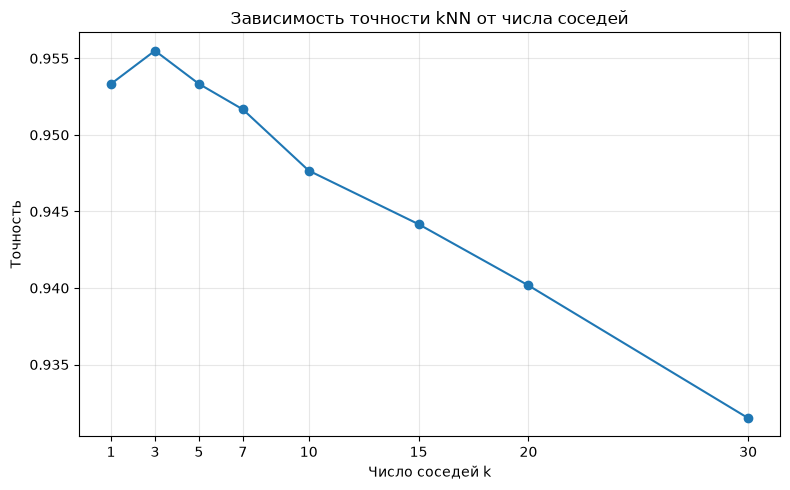

In [12]:
# Задаю значения k из задания.
k_values = [1, 3, 5, 7, 10, 15, 20, 30]
# Получаю все предсказания одним вычислением расстояний.
k_predictions = my_knn.predict_for_k_values(X_test, k_values)
# Считаю точность для каждого k.
k_accuracies = [accuracy_score(y_test, k_predictions[k]) for k in k_values]
# Нахожу лучшее значение k.
best_k_index = int(np.argmax(k_accuracies))
best_k = k_values[best_k_index]
print(f"Лучшее k в эксперименте: {best_k}")
print(f"Лучшая точность: {k_accuracies[best_k_index]:.4f}")

# Строю график точности от числа соседей.
plt.figure(figsize=(8, 5))
plt.plot(k_values, k_accuracies, "o-")
plt.xlabel("Число соседей k")
plt.ylabel("Точность")
plt.title("Зависимость точности kNN от числа соседей")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "knn_accuracy_by_k.png", dpi=150)
plt.show()


Лучшее число компонент при k=5: 50
Лучшая точность PCA + kNN: 0.9638
Общее время PCA-fit + transform + kNN для лучшего варианта: 5.53 с
Из них PCA-fit (общая обученная модель): 3.81 с
Проекция train/test: 0.03 с
kNN fit + predict: 1.69 с


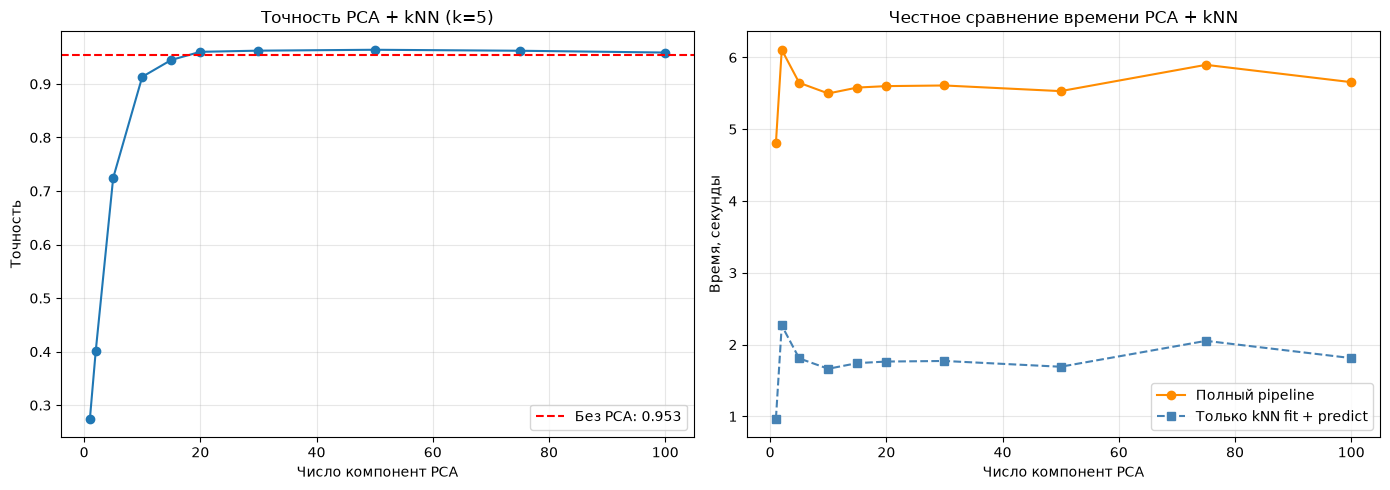

In [13]:
# PCA уже обучен только на X_train в ячейке выше; pca_fit_time включает его SVD.
# Для каждого числа компонент отдельно замеряю проекцию train/test и работу kNN.
# Время полного конвейера складывается из PCA-fit + transform + kNN fit/predict.
n_components_list = [1, 2, 5, 10, 15, 20, 30, 50, 75, 100]
n_components_list = [n for n in n_components_list if n <= pca_full.n_components_]
pca_accuracies = []
pca_transform_times = []
pca_knn_times = []
pca_total_times = []

for n_components in n_components_list:
    # Замеряю только проекцию исходных изображений на первые n компонент.
    transform_start = time.perf_counter()
    X_train_reduced = pca_full.transform(X_train, n_components=n_components)
    X_test_reduced = pca_full.transform(X_test, n_components=n_components)
    transform_elapsed = time.perf_counter() - transform_start

    # Замеряю kNN fit и predict отдельно от PCA.
    model = my_kNN(n_neighbors=5)
    knn_start = time.perf_counter()
    model.fit(X_train_reduced, y_train)
    predictions = model.predict(X_test_reduced)
    knn_elapsed = time.perf_counter() - knn_start

    pca_accuracies.append(accuracy_score(y_test, predictions))
    pca_transform_times.append(transform_elapsed)
    pca_knn_times.append(knn_elapsed)
    # Для каждого варианта считаю полный pipeline, а не только поиск соседей.
    pca_total_times.append(pca_fit_time + transform_elapsed + knn_elapsed)

best_pca_index = int(np.argmax(pca_accuracies))
best_components = n_components_list[best_pca_index]
print(f"Лучшее число компонент при k=5: {best_components}")
print(f"Лучшая точность PCA + kNN: {pca_accuracies[best_pca_index]:.4f}")
print(f"Общее время PCA-fit + transform + kNN для лучшего варианта: {pca_total_times[best_pca_index]:.2f} с")
print(f"Из них PCA-fit (общая обученная модель): {pca_fit_time:.2f} с")
print(f"Проекция train/test: {pca_transform_times[best_pca_index]:.2f} с")
print(f"kNN fit + predict: {pca_knn_times[best_pca_index]:.2f} с")

# Рисую точность и полное время работы в зависимости от числа компонент.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(n_components_list, pca_accuracies, "o-")
axes[0].axhline(accuracy_my, color="red", linestyle="--", label=f"Без PCA: {accuracy_my:.3f}")
axes[0].set_xlabel("Число компонент PCA")
axes[0].set_ylabel("Точность")
axes[0].set_title("Точность PCA + kNN (k=5)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(n_components_list, pca_total_times, "o-", color="darkorange", label="Полный pipeline")
axes[1].plot(n_components_list, pca_knn_times, "s--", color="steelblue", label="Только kNN fit + predict")
axes[1].set_xlabel("Число компонент PCA")
axes[1].set_ylabel("Время, секунды")
axes[1].set_title("Честное сравнение времени PCA + kNN")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "pca_knn_accuracy_time.png", dpi=150)
plt.show()


Лучшая комбинация: PCA=50, k=3
Максимальная точность: 0.9640
Минимальная точность: 0.6725


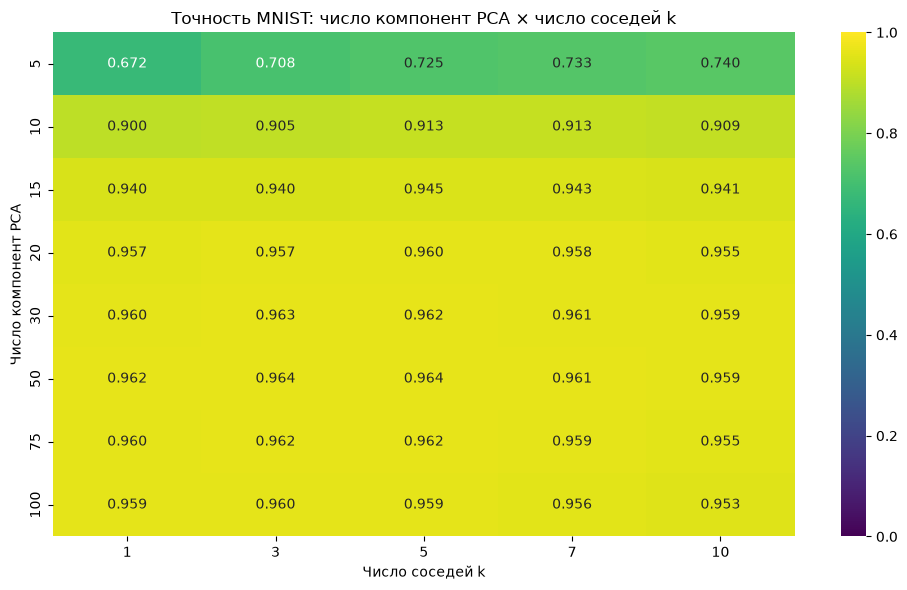

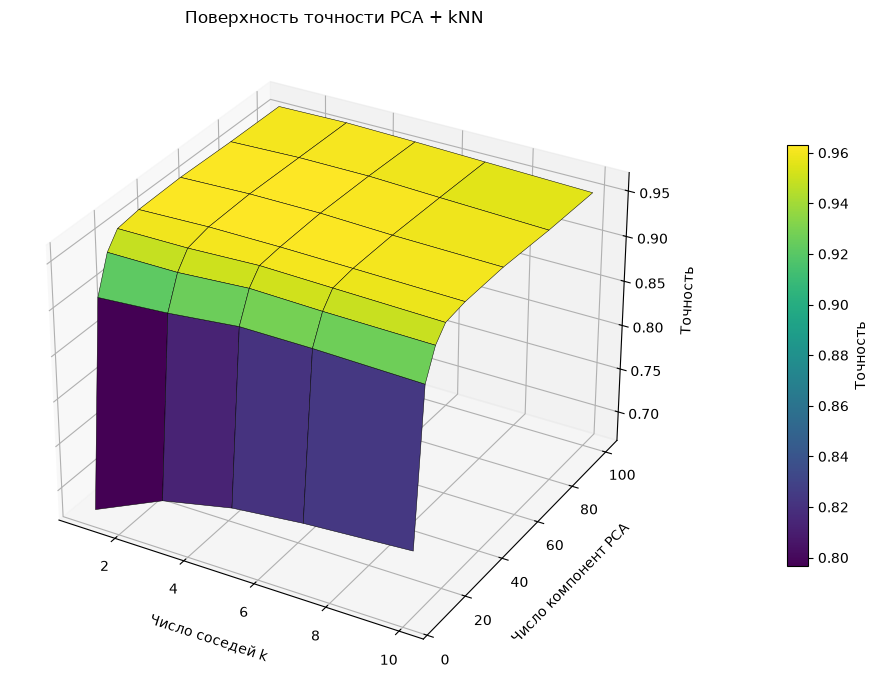

In [14]:
# Исследую совместное влияние числа компонент PCA и числа соседей k.
n_components_grid = [5, 10, 15, 20, 30, 50, 75, 100]
k_grid = [1, 3, 5, 7, 10]
accuracy_matrix = np.zeros((len(n_components_grid), len(k_grid)))

for row, n_components in enumerate(n_components_grid):
    # Проецирую train и test на первые n компонент именно для этой строки сетки.
    X_train_reduced = pca_full.transform(X_train, n_components=n_components)
    X_test_reduced = pca_full.transform(X_test, n_components=n_components)

    # Для данной размерности один раз нахожу соседей до максимального k.
    grid_knn = my_kNN(n_neighbors=max(k_grid))
    grid_knn.fit(X_train_reduced, y_train)
    grid_predictions = grid_knn.predict_for_k_values(X_test_reduced, k_grid)
    for column, k in enumerate(k_grid):
        accuracy_matrix[row, column] = accuracy_score(y_test, grid_predictions[k])

best_row, best_column = np.unravel_index(np.argmax(accuracy_matrix), accuracy_matrix.shape)
print(f"Лучшая комбинация: PCA={n_components_grid[best_row]}, k={k_grid[best_column]}")
print(f"Максимальная точность: {accuracy_matrix[best_row, best_column]:.4f}")
print(f"Минимальная точность: {accuracy_matrix.min():.4f}")

# Тепловая карта: x — число соседей, y — число компонент; цвет и подпись — точность.
plt.figure(figsize=(10, 6))
sns.heatmap(
    accuracy_matrix, annot=True, fmt=".3f", cmap="viridis",
    xticklabels=k_grid, yticklabels=n_components_grid,
    vmin=0, vmax=1
)
plt.xlabel("Число соседей k")
plt.ylabel("Число компонент PCA")
plt.title("Точность MNIST: число компонент PCA × число соседей k")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "pca_knn_heatmap.png", dpi=150)
plt.show()

# Дополнительный 3D-график той же таблицы: x — k, y — число компонент, z — точность.
K_mesh, component_mesh = np.meshgrid(k_grid, n_components_grid)
fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection="3d")
surface = ax.plot_surface(
    K_mesh, component_mesh, accuracy_matrix,
    cmap="viridis", edgecolor="black", linewidth=0.35, antialiased=True
)
ax.set_xlabel("Число соседей k", labelpad=10)
ax.set_ylabel("Число компонент PCA", labelpad=10)
ax.set_zlabel("Точность", labelpad=8)
ax.set_title("Поверхность точности PCA + kNN")
fig.colorbar(surface, ax=ax, shrink=0.65, pad=0.12, label="Точность")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "pca_knn_accuracy_surface.png", dpi=150)
plt.show()


In [15]:
# Проверяю размеры данных и результатов эксперимента.
assert X_work.shape == (WORKING_SAMPLES, 784)
assert len(X_train) + len(X_test) == WORKING_SAMPLES
assert Y_work.shape == (WORKING_SAMPLES, visualization_components)
assert y_pred_my.shape == y_test.shape
assert accuracy_matrix.shape == (len(n_components_grid), len(k_grid))
assert len(pca_total_times) == len(n_components_list)
assert np.all((np.asarray(pca_accuracies) >= 0) & (np.asarray(pca_accuracies) <= 1))
assert np.all((accuracy_matrix >= 0) & (accuracy_matrix <= 1))
assert pca_full.explained_variance_[0] >= pca_full.explained_variance_[1]
print("Все автоматические проверки пройдены.")
print("Размер выборки:", WORKING_SAMPLES)
print("Результаты и графики сохраняются в:", RESULTS_DIR)


Все автоматические проверки пройдены.
Размер выборки: 20000
Результаты и графики сохраняются в: attached_assets\mnist_pca_knn_results


## Итоговые выводы

1. В эксперименте используется стратифицированная рабочая выборка из **20 000** изображений MNIST; она разделяется на train и test в отношении 70/30.
2. PCA обучается только на обучающей части, а тестовые данные лишь проецируются на найденные компоненты.
3. Для PCA + kNN время считается корректно: отдельно измеряются обучение PCA, проекция train/test, обучение kNN и предсказание; график полного времени включает все три этапа.
4. Для перебора разных `k` ближайшие соседи сортируются по расстоянию после `argpartition`; поэтому первые `k` элементов действительно соответствуют ближайшим соседям.
5. Совместное влияние числа компонент PCA и числа соседей отображается на тепловой карте и 3D-поверхности: оси показывают число компонент и `k`, высота/цвет — точность.
6. При интерпретации результатов учитываются размер рабочей выборки, разбиение данных и выбранные параметры сетки.
